In [1]:
import os
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
import cv2
import sys
from skimage.feature import hog
from skimage.feature import local_binary_pattern
from sklearn.model_selection import GridSearchCV, cross_val_score,StratifiedKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt


## Read Data

In [48]:
import os
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split
import mahotas
import scipy.stats
import random

image_dir = "./Dataset"
categories = ['Bus', 'Car', 'motorcycle', 'Truck']
all_images = []
labels = []

for category in categories:
    category_dir = os.path.join(image_dir, category)
    category_images = [os.path.join(category_dir, filename) for filename in os.listdir(category_dir)]
    all_images.extend(category_images)
    labels.extend([category] * len(category_images))

## Train Test Split¶

In [50]:
# Train-Test split for machine learning
ml_train_images, ml_test_images, ml_train_labels, ml_test_labels = train_test_split(all_images, labels, test_size=0.2, random_state=42)

new_size = (256, 256)
ml_train_features = [] 
ml_val_features = []
ml_test_features = []

## Feauture Extractions

In [4]:
def extract_hog_features(image):
    hog_features = hog(image, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
    return hog_features

def extract_color_histogram(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv_image], [0], None, [256], [0, 256])
    hist_s = cv2.calcHist([hsv_image], [1], None, [256], [0, 256])
    hist_v = cv2.calcHist([hsv_image], [2], None, [256], [0, 256])
    color_hist = np.concatenate((hist_h, hist_s, hist_v), axis=None)
    return color_hist

def extract_lbp_features(image):
    lbp_image = local_binary_pattern(image, P=8, R=1, method='default')
    hist, _ = np.histogram(lbp_image.ravel(), bins=np.arange(0, 10), range=(0, 10))
    return hist

def extract_gabor_features(image):
    filters = []
    for theta in range(4):
        theta = theta / 4. * np.pi
        kernel = cv2.getGaborKernel((21, 21), 5.0, theta, 10.0, 1, 0, ktype=cv2.CV_32F)
        filters.append(kernel)
    feats = []
    for kernel in filters:
        filtered = cv2.filter2D(image, cv2.CV_8UC3, kernel)
        hist = cv2.calcHist([filtered], [0], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        feats.extend(hist)
    return feats

def extract_lpq_features(image):
    lpq = mahotas.features.lbp(image, 8, 1, ignore_zeros=False)
    hist, _ = np.histogram(lpq.ravel(), bins=np.arange(0, 10), range=(0, 10))
    return hist

def extract_features(image):
    resize_image = cv2.resize(image, new_size)
    gray_image = cv2.cvtColor(resize_image, cv2.COLOR_BGR2GRAY)

    hog_features = extract_hog_features(gray_image)
    color_hist = extract_color_histogram(resize_image)
    lbp_features = extract_lbp_features(gray_image)
    gabor_features = extract_gabor_features(gray_image)
    lpq_features = extract_lpq_features(gray_image)
    
    features = np.concatenate((hog_features, color_hist, lbp_features, gabor_features, lpq_features), axis=None)
    
    return features

## Data Augmentation

In [5]:
def augment_data(images, labels):
    augmented_images = []
    augmented_labels = []
    for image, label in zip(images, labels):
        # Brightness
        brightness_factor = random.uniform(0.5, 2.0)  # Adjust brightness between 0.5 and 2.0
        augmented_image = cv2.convertScaleAbs(image, alpha=brightness_factor, beta=0)

        # Rotation 
        angle = random.randint(-15, 15)  # Rotate between -15 and 15 degrees
        rows, cols = augmented_image.shape[:2]
        rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
        augmented_image = cv2.warpAffine(augmented_image, rotation_matrix, (cols, rows))

        augmented_images.append(augmented_image)
        augmented_labels.append(label)
    return augmented_images, augmented_labels

## Feature Extractions 

### Apply  in original train with augmented

In [51]:
ml_train_features = []
ml_train_labels = list(ml_train_labels)
ml_test_features = []

for image_path in ml_train_images:
    ml_train_features.append(extract_features(cv2.imread(image_path)))

augmented_train_images, augmented_train_labels = augment_data([cv2.imread(image_path) for image_path in ml_train_images], ml_train_labels)

for image, label in zip(augmented_train_images, augmented_train_labels):
    ml_train_features.append(extract_features(image))
    ml_train_labels.append(label)

ml_train_labels_augmented = np.array(ml_train_labels + augmented_train_labels)
ml_train_features = np.array(ml_train_features)


for image_path in ml_test_images:
    ml_test_features.append(extract_features(cv2.imread(image_path)))

ml_test_features = np.array(ml_test_features)

ml_train_labels = np.array(ml_train_labels)

ml_test_labels = np.array(ml_test_labels)

print("Train Features Shape:", ml_train_features.shape)
print("Train Labels Shape:", ml_train_labels.shape)

Train Features Shape: (640, 3858)
Train Labels Shape: (640,)


In [ ]:
print("TestFeatures Shape:", ml_test_features.shape)
print("Test Labels Shape:", ml_test_labels.shape)

TestFeatures Shape: (81, 3858)
Test Labels Shape: (81,)


In [8]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
fold = 1
for train_index, test_index in kf.split(ml_train_features, ml_train_labels):
    train_data_count = len(train_index)
    test_data_count = len(test_index)
    
    print(f"Fold {fold}:")
    print(f"Number of image for training set: {train_data_count}")
    print(f"Number of image for validation set: {test_data_count}\n")
    
    fold += 1

Fold 1:
Number of image for training set: 576
Number of image for validation set: 64

Fold 2:
Number of image for training set: 576
Number of image for validation set: 64

Fold 3:
Number of image for training set: 576
Number of image for validation set: 64

Fold 4:
Number of image for training set: 576
Number of image for validation set: 64

Fold 5:
Number of image for training set: 576
Number of image for validation set: 64

Fold 6:
Number of image for training set: 576
Number of image for validation set: 64

Fold 7:
Number of image for training set: 576
Number of image for validation set: 64

Fold 8:
Number of image for training set: 576
Number of image for validation set: 64

Fold 9:
Number of image for training set: 576
Number of image for validation set: 64

Fold 10:
Number of image for training set: 576
Number of image for validation set: 64



## Comparison train data with Data Augmentations

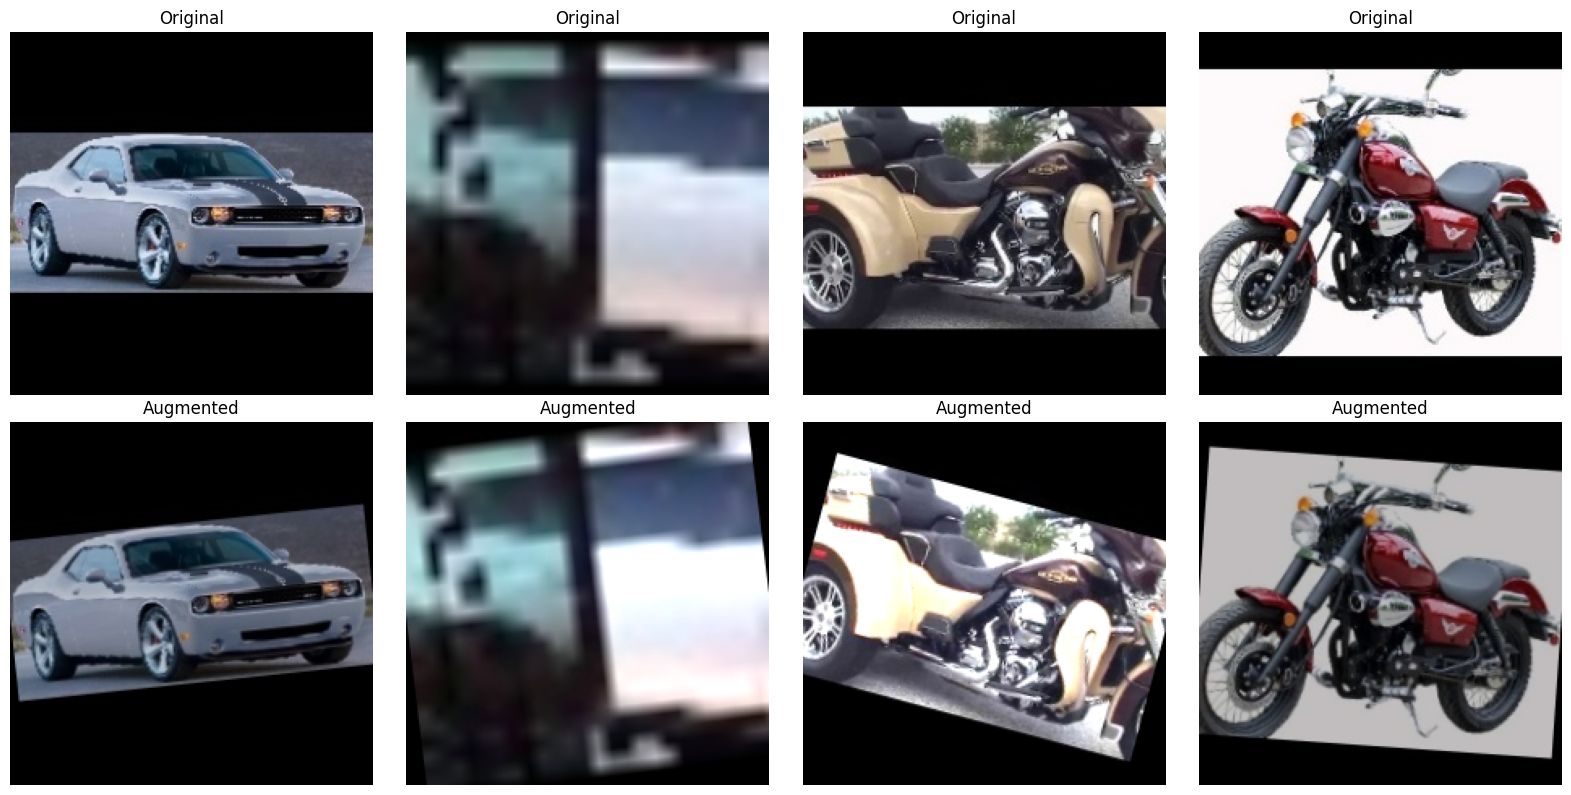

In [ ]:
import matplotlib.pyplot as plt

# Select 4 random indices from the original training set
original_indices = np.random.choice(len(ml_train_images), 4, replace=False)

# Select 4 corresponding augmented images
augmented_images = [augmented_train_images[i] for i in original_indices]

# Display original and augmented images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, idx in enumerate(original_indices):
    original_image = cv2.imread(ml_train_images[idx])
    augmented_image = augmented_images[i]

    axes[0, i].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("Augmented")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Machine Learning

### Set Hyperparameter Tuning with 10-fold validation

In [ ]:
svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'poly'],
    'class_weight': ['balanced', None]
}

knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1,2]
}

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

### Apply Support vector machine, K-nearest neighbour, Random Forest, Ensemble Learning (Voting and Stacking)

In [ ]:
svc_grid = GridSearchCV(SVC(), svc_params, cv=kf)
svc_grid.fit(ml_train_features, ml_train_labels)

NameError: name 'ml_train_labels' is not defined

In [ ]:
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=kf)
knn_grid.fit(ml_train_features, ml_train_labels)

e:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "e:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python312\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python312\Lib\site-packages\sklearn\neighbors\_classification.py", line 450, in score
    return super().score(X, y, sample_weight)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Python312\Lib\site-packages\sklearn\base.py", line 566, in score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
                           

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [ ]:
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=kf)
rf_grid.fit(ml_train_features, ml_train_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [ ]:
voting_classifier = VotingClassifier(estimators=[
    ('svc', svc_grid.best_estimator_),
    ('knn', knn_grid.best_estimator_),
    ('rf', rf_grid.best_estimator_)
], voting='hard')
voting_classifier.fit(ml_train_features, ml_train_labels)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svc', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [ ]:
stacking_classifier = StackingClassifier(estimators=[
    ('svc', svc_grid.best_estimator_),
    ('knn', knn_grid.best_estimator_),
    ('rf', rf_grid.best_estimator_)
], final_estimator=LogisticRegression())

stacking_classifier.fit(ml_train_features, ml_train_labels)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svc', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree

In [ ]:
voting_scores = cross_val_score(voting_classifier, ml_train_features, ml_train_labels, cv=10)
stacking_scores = cross_val_score(stacking_classifier, ml_train_features, ml_train_labels, cv=10)

e:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
e:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation

### Prediction and Evaluation Peformance Metrics Machine Learning

Metrics for SVM:
Accuracy: 0.4691358024691358
Sensitivity (Recall): {'Bus': 0.3870967741935484, 'Car': 0.75, 'motorcycle': 0.26666666666666666, 'Truck': 0.5263157894736842}
Specificity: {'Bus': 0.84, 'Car': 0.8, 'motorcycle': 0.8939393939393939, 'Truck': 0.7580645161290323}
Classification Report:
              precision    recall  f1-score   support

         Bus       0.60      0.39      0.47        31
         Car       0.48      0.75      0.59        16
       Truck       0.36      0.27      0.31        15
  motorcycle       0.40      0.53      0.45        19

    accuracy                           0.47        81
   macro avg       0.46      0.48      0.45        81
weighted avg       0.49      0.47      0.46        81



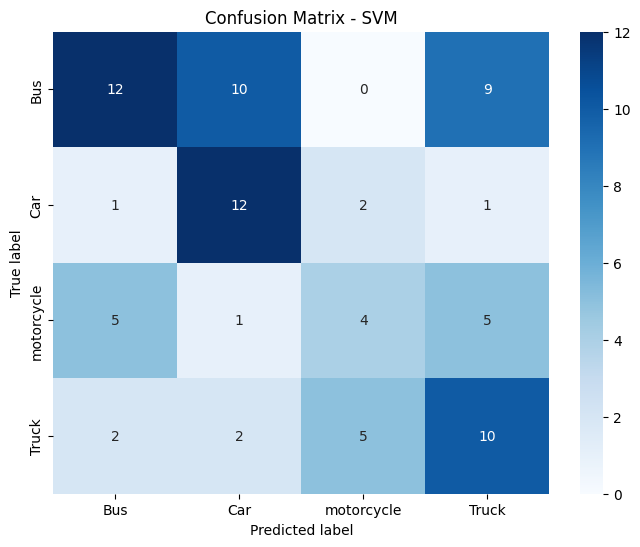

Metrics for KNN:
Accuracy: 0.41975308641975306
Sensitivity (Recall): {'Bus': 0.45161290322580644, 'Car': 0.5, 'motorcycle': 0.26666666666666666, 'Truck': 0.42105263157894735}
Specificity: {'Bus': 0.82, 'Car': 0.9076923076923077, 'motorcycle': 0.803030303030303, 'Truck': 0.6935483870967742}
Classification Report:
              precision    recall  f1-score   support

         Bus       0.61      0.45      0.52        31
         Car       0.57      0.50      0.53        16
       Truck       0.24      0.27      0.25        15
  motorcycle       0.30      0.42      0.35        19

    accuracy                           0.42        81
   macro avg       0.43      0.41      0.41        81
weighted avg       0.46      0.42      0.43        81



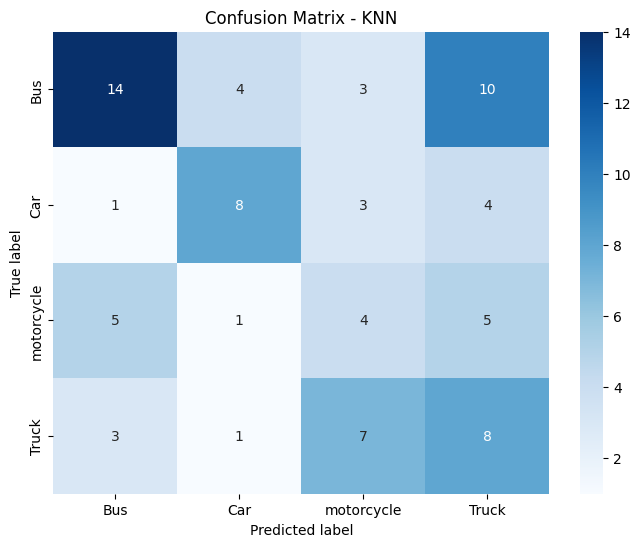

Metrics for Random Forest:
Accuracy: 0.6666666666666666
Sensitivity (Recall): {'Bus': 0.5806451612903226, 'Car': 0.8125, 'motorcycle': 0.3333333333333333, 'Truck': 0.9473684210526315}
Specificity: {'Bus': 0.8, 'Car': 0.8769230769230769, 'motorcycle': 0.9090909090909091, 'Truck': 0.9516129032258065}
Classification Report:
              precision    recall  f1-score   support

         Bus       0.64      0.58      0.61        31
         Car       0.62      0.81      0.70        16
       Truck       0.45      0.33      0.38        15
  motorcycle       0.86      0.95      0.90        19

    accuracy                           0.67        81
   macro avg       0.64      0.67      0.65        81
weighted avg       0.65      0.67      0.65        81



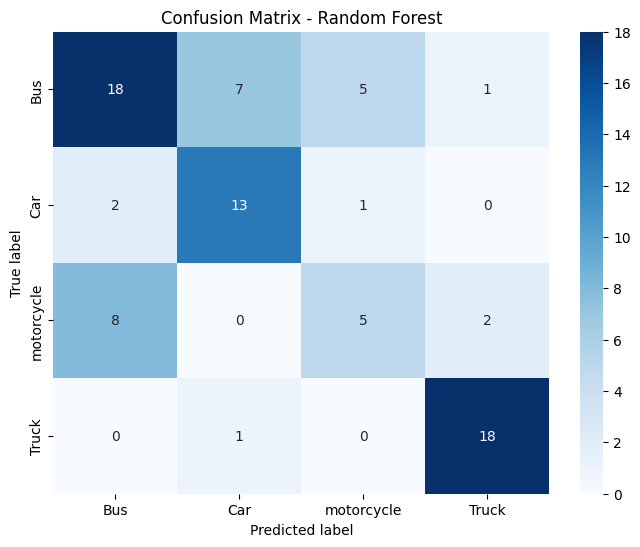

Metrics for Voting Classifier:
Accuracy: 0.5061728395061729
Sensitivity (Recall): {'Bus': 0.5161290322580645, 'Car': 0.75, 'motorcycle': 0.2, 'Truck': 0.5263157894736842}
Specificity: {'Bus': 0.8, 'Car': 0.8307692307692308, 'motorcycle': 0.8939393939393939, 'Truck': 0.8064516129032258}
Classification Report:
              precision    recall  f1-score   support

         Bus       0.62      0.52      0.56        31
         Car       0.52      0.75      0.62        16
       Truck       0.30      0.20      0.24        15
  motorcycle       0.45      0.53      0.49        19

    accuracy                           0.51        81
   macro avg       0.47      0.50      0.48        81
weighted avg       0.50      0.51      0.50        81



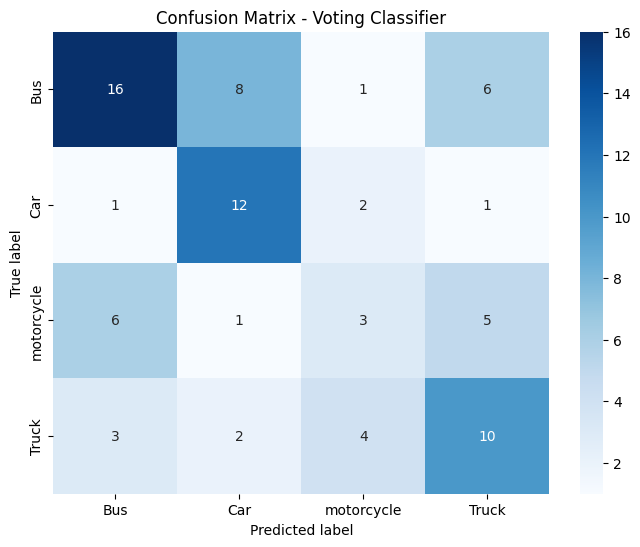

Metrics for Stacking Classifier:
Accuracy: 0.49382716049382713
Sensitivity (Recall): {'Bus': 0.5161290322580645, 'Car': 0.625, 'motorcycle': 0.26666666666666666, 'Truck': 0.5263157894736842}
Specificity: {'Bus': 0.8, 'Car': 0.8923076923076924, 'motorcycle': 0.8484848484848485, 'Truck': 0.7741935483870968}
Classification Report:
              precision    recall  f1-score   support

         Bus       0.62      0.52      0.56        31
         Car       0.59      0.62      0.61        16
       Truck       0.29      0.27      0.28        15
  motorcycle       0.42      0.53      0.47        19

    accuracy                           0.49        81
   macro avg       0.48      0.48      0.48        81
weighted avg       0.50      0.49      0.49        81



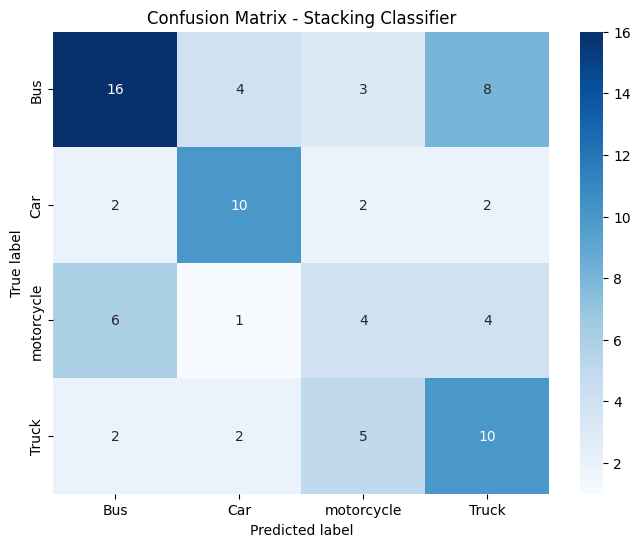

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_classifier(classifier, classifier_name, test_features, test_labels):
    predictions = classifier.predict(test_features)
    acc = accuracy_score(test_labels, predictions)
    conf_matrix = confusion_matrix(test_labels, predictions)
    cls_report = classification_report(test_labels, predictions)
    
    true_positives = np.diag(conf_matrix)
    false_positives = np.sum(conf_matrix, axis=0) - true_positives
    false_negatives = np.sum(conf_matrix, axis=1) - true_positives
    true_negatives = np.sum(conf_matrix) - (true_positives + false_positives + false_negatives)

    sensitivity = true_positives / (true_positives + false_negatives)
    specificity = true_negatives / (true_negatives + false_positives)

    sensitivity_dict = {categories[i]: sensitivity[i] for i in range(len(categories))}
    specificity_dict = {categories[i]: specificity[i] for i in range(len(categories))}

    print(f"Metrics for {classifier_name}:")
    print("Accuracy:", acc)
    print("Sensitivity (Recall):", sensitivity_dict)
    print("Specificity:", specificity_dict)
    print("Classification Report:")
    print(cls_report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=categories, yticklabels=categories)
    plt.title(f"Confusion Matrix - {classifier_name}")
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

classifiers = [svc_grid.best_estimator_, knn_grid.best_estimator_, rf_grid.best_estimator_, voting_classifier, stacking_classifier]
classifier_names = ['SVM', 'KNN', 'Random Forest', 'Voting Classifier', 'Stacking Classifier']

for classifier, classifier_name in zip(classifiers, classifier_names):
    evaluate_classifier(classifier, classifier_name, ml_test_features, ml_test_labels)

## Deep Learning

## Read Dataset and Split Train Test Data

In [19]:
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from sklearn.model_selection import train_test_split

image_dir = "./Dataset"
categories = ['Bus', 'Car', 'motorcycle', 'Truck']
batch_size = 32
img_height = 100
img_width = 100
num_classes = len(categories)
num_folds = 10
test_size = 0.2 


train_val_data = tf.keras.preprocessing.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels="inferred",
    label_mode="int",
    class_names=categories,
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    labels="inferred",
    label_mode="int",
    class_names=categories,
)


Found 401 files belonging to 4 classes.
Using 321 files for training.
Found 401 files belonging to 4 classes.
Using 80 files for validation.


## Split Dataset ; Train, Validation, Test Dataset

In [ ]:
dl_train_val_images = []
dl_train_val_labels = []
for images, labels in train_val_data:
    dl_train_val_images.append(images.numpy())
    dl_train_val_labels.append(labels.numpy())
dl_train_val_images = np.vstack(dl_train_val_images)
dl_train_val_labels = np.concatenate(dl_train_val_labels)

dl_test_images = []
dl_test_labels = []
for images, labels in test_data:
    dl_test_images.append(images.numpy())
    dl_test_labels.append(labels.numpy())
dl_test_images = np.vstack(dl_test_images)
dl_test_labels = np.concatenate(dl_test_labels)

dl_train_images, dl_val_images, dl_train_labels, dl_val_labels = train_test_split(
    dl_train_val_images, dl_train_val_labels, test_size=0.2, random_state=42
)

## Data Augmentation

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

dl_train_images_augmented = data_augmentation(dl_train_images)

dl_train_images_combined = np.concatenate([dl_train_images, dl_train_images_augmented])
dl_train_labels_combined = np.concatenate([dl_train_labels, dl_train_labels])


AUTOTUNE = tf.data.AUTOTUNE
dl_train_data = tf.data.Dataset.from_tensor_slices((dl_train_images_combined, dl_train_labels_combined)).prefetch(buffer_size=AUTOTUNE)
dl_val_data = tf.data.Dataset.from_tensor_slices((dl_val_images, dl_val_labels)).prefetch(buffer_size=AUTOTUNE)
dl_test_data = tf.data.Dataset.from_tensor_slices((dl_test_images, dl_test_labels)).prefetch(buffer_size=AUTOTUNE)

## Fully connected neural network With Hyperparamter Tuning

In [ ]:
def build_model(X=None, y=None, learning_rate=0.005, optimizer='adam', dropout_rate=0.2, hidden_units=128):
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
        
    model = Sequential([
        layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
        layers.Flatten(),
        layers.Dense(hidden_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes)
    ])
    model.compile(optimizer=opt,
                  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model


# 由于SKLearnClassifier在Keras 3.x中不支持通过GridSearchCV进行超参数调优
# 我们使用手动交叉验证进行超参数调优

from itertools import product
from sklearn.utils.class_weight import compute_class_weight

# 定义参数网格
param_grid = {
    'hidden_units': [128, 256],
    'learning_rate': [0.001, 0.01],
    'optimizer': ['adam']
}

# 生成所有参数组合
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
param_combinations = list(product(*param_values))

# 创建交叉验证分割
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# 遍历所有参数组合
for i, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    print(f"\n测试参数组合 {i+1}/{len(param_combinations)}: {param_dict}")
    
    fold_scores = []
    
    # 交叉验证
    for fold, (train_idx, val_idx) in enumerate(kf.split(dl_train_images_combined, dl_train_labels_combined)):
        # 分割数据
        X_train_fold, X_val_fold = dl_train_images_combined[train_idx], dl_train_images_combined[val_idx]
        y_train_fold, y_val_fold = dl_train_labels_combined[train_idx], dl_train_labels_combined[val_idx]
        
        # 计算类别权重
        class_weight = compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
        class_weight = dict(enumerate(class_weight))
        
        # 构建模型
        model = build_model(**param_dict)
        
        # 训练模型
        history = model.fit(
            X_train_fold, y_train_fold,
            epochs=10,
            batch_size=32,
            validation_data=(X_val_fold, y_val_fold),
            class_weight=class_weight,
            steps_per_epoch=max(1, len(X_train_fold)//32),
            verbose=0
        )
        
        # 评估模型
        val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        fold_scores.append(val_accuracy)
        
        print(f"  折 {fold+1}: 验证准确率 = {val_accuracy:.4f}")
    
    # 计算平均得分
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    
    print(f"  平均验证准确率: {mean_score:.4f} (±{std_score:.4f})")
    
    results.append({
        'params': param_dict,
        'mean_score': mean_score,
        'std_score': std_score,
        'fold_scores': fold_scores
    })

# 找到最佳参数
best_result = max(results, key=lambda x: x['mean_score'])
best_params = best_result['params']
best_score = best_result['mean_score']

print(f"\n最佳参数: {best_params}")
print(f"最佳验证准确率: {best_score:.4f}")

# 计算最终模型的类别权重
class_weight = compute_class_weight('balanced', classes=np.unique(dl_train_labels_combined), y=dl_train_labels_combined)
class_weight = dict(enumerate(class_weight))

# 使用最佳参数训练最终模型
best_model_mlp = build_model(**best_params)
best_model_mlp.fit(
    dl_train_images_combined, dl_train_labels_combined,
    epochs=10,
    batch_size=32,
    validation_data=(dl_val_images, dl_val_labels),
    class_weight=class_weight,
    steps_per_epoch=max(1, len(dl_train_images_combined)//32),
    verbose=0
)

# 评估最终模型
test_loss, test_accuracy = best_model_mlp.evaluate(dl_test_images, dl_test_labels, verbose=0)
print("\n最终模型测试准确率:", test_accuracy)


测试参数组合 1/4: {'hidden_units': 128, 'learning_rate': 0.001, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.3269


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.5192


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.5098


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.5490


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.6078


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.5686


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.5882


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.5294


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.5294


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.5490
  平均验证准确率: 0.5278 (±0.0731)

测试参数组合 2/4: {'hidden_units': 128, 'learning_rate': 0.01, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.3654


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.4231


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.4902


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.4314


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.4118


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.4510


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.4118


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.5294


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.2941


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.2745
  平均验证准确率: 0.4083 (±0.0753)

测试参数组合 3/4: {'hidden_units': 256, 'learning_rate': 0.001, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.5000


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.5385


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.5294


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.5098


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.6471


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.5490


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.5686


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.5098


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.6078


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.6078
  平均验证准确率: 0.5568 (±0.0472)

测试参数组合 4/4: {'hidden_units': 256, 'learning_rate': 0.01, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.4615


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.3654


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.4706


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.4118


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.5686


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.5098


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.5098


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.4118


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.4118


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.4118
  平均验证准确率: 0.4533 (±0.0589)

最佳参数: {'hidden_units': 256, 'learning_rate': 0.001, 'optimizer': 'adam'}
最佳验证准确率: 0.5568


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



最终模型测试准确率: 0.6625000238418579


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Metrics for Fully connected neural network:
Accuracy: 0.6625
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60        22
           1       0.80      0.80      0.80        20
           2       0.75      0.65      0.70        23
           3       0.53      0.53      0.53        15

    accuracy                           0.66        80
   macro avg       0.66      0.66      0.66        80
weighted avg       0.67      0.66      0.66        80



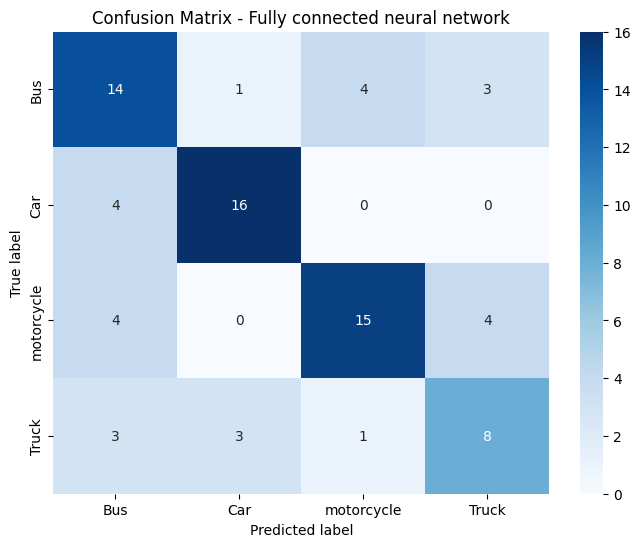

In [ ]:
def evaluate_classifier(classifier, classifier_name, test_features, test_labels):
    predictions = classifier.predict(test_features)
    predictions = np.argmax(predictions, axis=1)  # Convert logits to class predictions
    acc = accuracy_score(test_labels, predictions)
    conf_matrix = confusion_matrix(test_labels, predictions)
    cls_report = classification_report(test_labels, predictions)
    
    print(f"Metrics for {classifier_name}:")
    print("Accuracy:", acc)
    print("Classification Report:")
    print(cls_report)

    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=categories, yticklabels=categories)
    plt.title(f"Confusion Matrix - {classifier_name}")
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

classifiers = [best_model_mlp]
classifier_names = ['Fully connected neural network']


for classifier, classifier_name in zip(classifiers, classifier_names):
    evaluate_classifier(classifier, classifier_name, dl_test_images, dl_test_labels)

## CNN With Hyperparamter Tuning

In [ ]:
def build_model(X=None, y=None, learning_rate=0.001, optimizer='adam', dropout_rate=0.2):
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
        
    model = Sequential([
        layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes)
    ])
    model.compile(optimizer=opt,
                  loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

from sklearn.utils.class_weight import compute_class_weight

# 由于SKLearnClassifier在Keras 3.x中不支持通过GridSearchCV进行超参数调优
# 我们使用手动交叉验证进行超参数调优

from itertools import product

# 定义参数网格
param_grid = {
    'learning_rate': [0.001, 0.01],
    'optimizer': ['adam']
}

# 生成所有参数组合
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
param_combinations = list(product(*param_values))

# 创建交叉验证分割
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# 遍历所有参数组合
for i, params in enumerate(param_combinations):
    param_dict = dict(zip(param_names, params))
    print(f"\n测试参数组合 {i+1}/{len(param_combinations)}: {param_dict}")
    
    fold_scores = []
    
    # 交叉验证
    for fold, (train_idx, val_idx) in enumerate(kf.split(dl_train_images, dl_train_labels)):
        # 分割数据
        X_train_fold, X_val_fold = dl_train_images[train_idx], dl_train_images[val_idx]
        y_train_fold, y_val_fold = dl_train_labels[train_idx], dl_train_labels[val_idx]
        
        # 计算类别权重
        class_weight = compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
        class_weight = dict(enumerate(class_weight))
        
        # 构建模型
        model = build_model(**param_dict)
        
        # 训练模型
        history = model.fit(
            X_train_fold, y_train_fold,
            epochs=20,
            batch_size=32,
            validation_data=(X_val_fold, y_val_fold),
            class_weight=class_weight,
            steps_per_epoch=max(1, len(X_train_fold)//32),
            verbose=0
        )
        
        # 评估模型
        val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        fold_scores.append(val_accuracy)
        
        print(f"  折 {fold+1}: 验证准确率 = {val_accuracy:.4f}")
    
    # 计算平均得分
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    
    print(f"  平均验证准确率: {mean_score:.4f} (±{std_score:.4f})")
    
    results.append({
        'params': param_dict,
        'mean_score': mean_score,
        'std_score': std_score,
        'fold_scores': fold_scores
    })

# 找到最佳参数
best_result = max(results, key=lambda x: x['mean_score'])
best_params = best_result['params']
best_score = best_result['mean_score']

print(f"\n最佳参数: {best_params}")
print(f"最佳验证准确率: {best_score:.4f}")

# 计算最终模型的类别权重
class_weight = compute_class_weight('balanced', classes=np.unique(dl_train_labels), y=dl_train_labels)
class_weight = dict(enumerate(class_weight))

# 使用最佳参数训练最终模型
best_model_cnn = build_model(**best_params)
best_model_cnn.fit(
    dl_train_images, dl_train_labels,
    epochs=5,
    batch_size=32,
    validation_data=(dl_val_images, dl_val_labels),
    class_weight=class_weight,
    steps_per_epoch=max(1, len(dl_train_images)//32),
    verbose=0
)

# 评估最终模型
test_loss, test_accuracy = best_model_cnn.evaluate(dl_test_images, dl_test_labels, verbose=0)
print("\n最终模型测试准确率:", test_accuracy)


测试参数组合 1/2: {'learning_rate': 0.001, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.6154


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.6538


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.6923


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.7308


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.6538


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.5385


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.5600


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.6400


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.5600


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.7200
  平均验证准确率: 0.6365 (±0.0643)

测试参数组合 2/2: {'learning_rate': 0.01, 'optimizer': 'adam'}


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 1: 验证准确率 = 0.3077


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 2: 验证准确率 = 0.1538


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 3: 验证准确率 = 0.1538


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 4: 验证准确率 = 0.7692


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 5: 验证准确率 = 0.2308


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 6: 验证准确率 = 0.3077


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 7: 验证准确率 = 0.2800


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 8: 验证准确率 = 0.4000


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 9: 验证准确率 = 0.2800


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
e:\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


  折 10: 验证准确率 = 0.5600
  平均验证准确率: 0.3443 (±0.1807)

最佳参数: {'learning_rate': 0.001, 'optimizer': 'adam'}
最佳验证准确率: 0.6365


e:\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



最终模型测试准确率: 0.762499988079071


## Evaluation CNN and Fully connected neural network

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001E0BDF95D00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Metrics for Convolutional neural network:
Accuracy: 0.7625
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.73      0.74        22
        

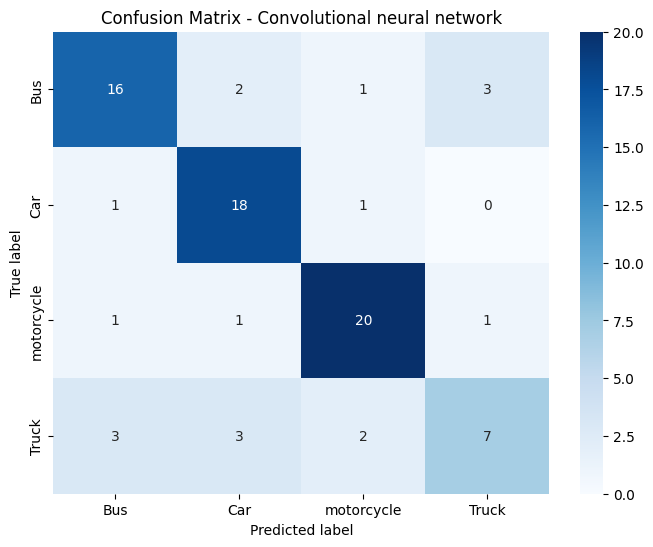

In [ ]:
def evaluate_classifier(classifier, classifier_name, test_features, test_labels):
    predictions = classifier.predict(test_features)
    predictions = np.argmax(predictions, axis=1)  # Convert logits to class predictions
    acc = accuracy_score(test_labels, predictions)
    conf_matrix = confusion_matrix(test_labels, predictions)
    cls_report = classification_report(test_labels, predictions)
    
    print(f"Metrics for {classifier_name}:")
    print("Accuracy:", acc)
    print("Classification Report:")
    print(cls_report)

    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=categories, yticklabels=categories)
    plt.title(f"Confusion Matrix - {classifier_name}")
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

classifiers = [best_model_cnn]
classifier_names = ['Convolutional neural network']


for classifier, classifier_name in zip(classifiers, classifier_names):
    evaluate_classifier(classifier, classifier_name, dl_test_images, dl_test_labels)

## Reference 

## The code used in this document is sourced from Python documentation, as well as lecture modules on Big Data Analytics and Modeling, and image processing for data science.
## Sandipan Dey (2018b). Hands-on image processing with Python : expert techniques for advanced image analysis and effective interpretation of image data. Birmingham, Uk: Packt Publishing Ltd.
